# Video Classification with a CNN-RNN Architecture

**Author:** [Sayak Paul](https://twitter.com/RisingSayak)<br>
**Date created:** 2021/05/28<br>
**Last modified:** 2023/12/08<br>
**Description:** Training a video classifier with transfer learning and a recurrent model on the UCF101 dataset.

This example demonstrates video classification, an important use-case with
applications in recommendations, security, and so on.
We will be using the [UCF101 dataset](https://www.crcv.ucf.edu/data/UCF101.php)
to build our video classifier. The dataset consists of videos categorized into different
actions, like cricket shot, punching, biking, etc. This dataset is commonly used to
build action recognizers, which are an application of video classification.

A video consists of an ordered sequence of frames. Each frame contains *spatial*
information, and the sequence of those frames contains *temporal* information. To model
both of these aspects, we use a hybrid architecture that consists of convolutions
(for spatial processing) as well as recurrent layers (for temporal processing).
Specifically, we'll use a Convolutional Neural Network (CNN) and a Recurrent Neural
Network (RNN) consisting of [GRU layers](https://keras.io/api/layers/recurrent_layers/gru/).
This kind of hybrid architecture is popularly known as a **CNN-RNN**.

This example requires TensorFlow 2.5 or higher, as well as TensorFlow Docs, which can be
installed using the following command:

In [1]:
!pip install -q git+https://github.com/tensorflow/docs

  Preparing metadata (setup.py) ... done


## Data collection

In order to keep the runtime of this example relatively short, we will be using a
subsampled version of the original UCF101 dataset. You can refer to
[this notebook](https://colab.research.google.com/github/sayakpaul/Action-Recognition-in-TensorFlow/blob/main/Data_Preparation_UCF101.ipynb)
to know how the subsampling was done.

In [2]:
!!wget -q https://github.com/sayakpaul/Action-Recognition-in-TensorFlow/releases/download/v1.0.0/ucf101_top5.tar.gz
!tar xf ucf101_top5.tar.gz

## Setup

In [3]:
import os

import keras
from imutils import paths

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import imageio
import cv2
from IPython.display import Image

## Define hyperparameters

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 10

MAX_SEQ_LENGTH = 20
NUM_FEATURES = 2048

## Data preparation

In [5]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(f"Total videos for training: {len(train_df)}")
print(f"Total videos for testing: {len(test_df)}")

train_df.sample(10)

Total videos for training: 594
Total videos for testing: 224


,video_name,tag
145,v_PlayingCello_g12_c01.avi,PlayingCello
130,v_PlayingCello_g09_c07.avi,PlayingCello
230,v_PlayingCello_g24_c07.avi,PlayingCello
141,v_PlayingCello_g11_c04.avi,PlayingCello
80,v_CricketShot_g20_c02.avi,CricketShot
233,v_PlayingCello_g25_c03.avi,PlayingCello
298,v_Punch_g16_c07.avi,Punch
150,v_PlayingCello_g12_c06.avi,PlayingCello
155,v_PlayingCello_g13_c04.avi,PlayingCello
524,v_TennisSwing_g14_c07.avi,TennisSwing


One of the many challenges of training video classifiers is figuring out a way to feed
the videos to a network. [This blog post](https://blog.coast.ai/five-video-classification-methods-implemented-in-keras-and-tensorflow-99cad29cc0b5)
discusses five such methods. Since a video is an ordered sequence of frames, we could
just extract the frames and put them in a 3D tensor. But the number of frames may differ
from video to video which would prevent us from stacking them into batches
(unless we use padding). As an alternative, we can **save video frames at a fixed
interval until a maximum frame count is reached**. In this example we will do
the following:

1. Capture the frames of a video.
2. Extract frames from the videos until a maximum frame count is reached.
3. In the case, where a video's frame count is lesser than the maximum frame count we
will pad the video with zeros.

Note that this workflow is identical to [problems involving texts sequences](https://developers.google.com/machine-learning/guides/text-classification/). Videos of the UCF101 dataset is [known](https://www.crcv.ucf.edu/papers/UCF101_CRCV-TR-12-01.pdf)
to not contain extreme variations in objects and actions across frames. Because of this,
it may be okay to only consider a few frames for the learning task. But this approach may
not generalize well to other video classification problems. We will be using
[OpenCV's `VideoCapture()` method](https://docs.opencv.org/master/dd/d43/tutorial_py_video_display.html)
to read frames from videos.

In [6]:
# The following two methods are taken from this tutorial:
# https://www.tensorflow.org/hub/tutorials/action_recognition_with_tf_hub


def crop_center_square(frame):
    y, x = frame.shape[0:2]
    min_dim = min(y, x)
    start_x = (x // 2) - (min_dim // 2)
    start_y = (y // 2) - (min_dim // 2)
    return frame[start_y : start_y + min_dim, start_x : start_x + min_dim]


def load_video(path, max_frames=0, resize=(IMG_SIZE, IMG_SIZE)):
    cap = cv2.VideoCapture(path)
    frames = []
    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame = crop_center_square(frame)
            frame = cv2.resize(frame, resize)
            frame = frame[:, :, [2, 1, 0]]
            frames.append(frame)

            if len(frames) == max_frames:
                break
    finally:
        cap.release()
    return np.array(frames)


We can use a pre-trained network to extract meaningful features from the extracted
frames. The [`Keras Applications`](https://keras.io/api/applications/) module provides
a number of state-of-the-art models pre-trained on the [ImageNet-1k dataset](http://image-net.org/).
We will be using the [InceptionV3 model](https://arxiv.org/abs/1512.00567) for this purpose.

In [7]:

def build_feature_extractor():
    feature_extractor = keras.applications.InceptionV3(
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    preprocess_input = keras.applications.inception_v3.preprocess_input

    inputs = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    preprocessed = preprocess_input(inputs)

    outputs = feature_extractor(preprocessed)
    return keras.Model(inputs, outputs, name="feature_extractor")


feature_extractor = build_feature_extractor()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


The labels of the videos are strings. Neural networks do not understand string values,
so they must be converted to some numerical form before they are fed to the model. Here
we will use the [`StringLookup`](https://keras.io/api/layers/preprocessing_layers/categorical/string_lookup)
layer encode the class labels as integers.

In [8]:
label_processor = keras.layers.StringLookup(
    num_oov_indices=0, vocabulary=np.unique(train_df["tag"])
)
print(label_processor.get_vocabulary())

[np.str_('CricketShot'), np.str_('PlayingCello'), np.str_('Punch'), np.str_('ShavingBeard'), np.str_('TennisSwing')]


Finally, we can put all the pieces together to create our data processing utility.

In [9]:

def prepare_all_videos(df, root_dir):
    num_samples = len(df)
    video_paths = df["video_name"].values.tolist()
    labels = df["tag"].values
    labels = keras.ops.convert_to_numpy(label_processor(labels[..., None]))

    # `frame_masks` and `frame_features` are what we will feed to our sequence model.
    # `frame_masks` will contain a bunch of booleans denoting if a timestep is
    # masked with padding or not.
    frame_masks = np.zeros(shape=(num_samples, MAX_SEQ_LENGTH), dtype="bool")
    frame_features = np.zeros(
        shape=(num_samples, MAX_SEQ_LENGTH, NUM_FEATURES), dtype="float32"
    )

    # For each video.
    for idx, path in enumerate(video_paths):
        # Gather all its frames and add a batch dimension.
        frames = load_video(os.path.join(root_dir, path))
        frames = frames[None, ...]

        # Initialize placeholders to store the masks and features of the current video.
        temp_frame_mask = np.zeros(
            shape=(
                1,
                MAX_SEQ_LENGTH,
            ),
            dtype="bool",
        )
        temp_frame_features = np.zeros(
            shape=(1, MAX_SEQ_LENGTH, NUM_FEATURES), dtype="float32"
        )

        # Extract features from the frames of the current video.
        for i, batch in enumerate(frames):
            video_length = batch.shape[0]
            length = min(MAX_SEQ_LENGTH, video_length)
            for j in range(length):
                temp_frame_features[i, j, :] = feature_extractor.predict(
                    batch[None, j, :], verbose=0,
                )
            temp_frame_mask[i, :length] = 1  # 1 = not masked, 0 = masked

        frame_features[idx,] = temp_frame_features.squeeze()
        frame_masks[idx,] = temp_frame_mask.squeeze()

    return (frame_features, frame_masks), labels


train_data, train_labels = prepare_all_videos(train_df, "train")
test_data, test_labels = prepare_all_videos(test_df, "test")

print(f"Frame features in train set: {train_data[0].shape}")
print(f"Frame masks in train set: {train_data[1].shape}")

Frame features in train set: (594, 20, 2048)
Frame masks in train set: (594, 20)


The above code block will take ~20 minutes to execute depending on the machine it's being
executed.

## The sequence model

Now, we can feed this data to a sequence model consisting of recurrent layers like `GRU`.

In [19]:

# Utility for our sequence model.
def get_sequence_model():
    class_vocab = label_processor.get_vocabulary()

    frame_features_input = keras.Input((MAX_SEQ_LENGTH, NUM_FEATURES))
    mask_input = keras.Input((MAX_SEQ_LENGTH,), dtype="bool")

    # Refer to the following tutorial to understand the significance of using `mask`:
    # https://keras.io/api/layers/recurrent_layers/gru/
    x = keras.layers.GRU(16, return_sequences=True)(
        frame_features_input, mask=mask_input
    )
    x = keras.layers.GRU(8)(x)
    x = keras.layers.Dropout(0.4)(x)
    x = keras.layers.Dense(8, activation="relu")(x)
    output = keras.layers.Dense(len(class_vocab), activation="softmax")(x)

    rnn_model = keras.Model([frame_features_input, mask_input], output)

    rnn_model.compile(
        loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"]
    )
    return rnn_model


# Utility for running experiments.
def run_experiment():
    filepath = "/tmp/video_classifier/ckpt.weights.h5"
    checkpoint = keras.callbacks.ModelCheckpoint(
        filepath, save_weights_only=True, save_best_only=True, verbose=1
    )

    seq_model = get_sequence_model()
    history = seq_model.fit(
        [train_data[0], train_data[1]],
        train_labels,
        validation_split=0.3,
        epochs=EPOCHS,
        callbacks=[checkpoint],
    )

    seq_model.load_weights(filepath)
    _, accuracy = seq_model.evaluate([test_data[0], test_data[1]], test_labels)
    print(f"Test accuracy: {round(accuracy * 100, 2)}%")

    return history, seq_model


_, sequence_model = run_experiment()

NameError: name 'train_data' is not defined

**Note**: To keep the runtime of this example relatively short, we just used a few
training examples. This number of training examples is low with respect to the sequence
model being used that has 99,909 trainable parameters. You are encouraged to sample more
data from the UCF101 dataset using [the notebook](https://colab.research.google.com/github/sayakpaul/Action-Recognition-in-TensorFlow/blob/main/Data_Preparation_UCF101.ipynb) mentioned above and train the same model.

## Inference

In [18]:

def prepare_single_video(frames):
    frames = frames[None, ...]
    frame_mask = np.zeros(
        shape=(
            1,
            MAX_SEQ_LENGTH,
        ),
        dtype="bool",
    )
    frame_features = np.zeros(shape=(1, MAX_SEQ_LENGTH, NUM_FEATURES), dtype="float32")

    for i, batch in enumerate(frames):
        video_length = batch.shape[0]
        length = min(MAX_SEQ_LENGTH, video_length)
        for j in range(length):
            frame_features[i, j, :] = feature_extractor.predict(batch[None, j, :])
        frame_mask[i, :length] = 1  # 1 = not masked, 0 = masked

    return frame_features, frame_mask


def sequence_prediction(path):
    class_vocab = label_processor.get_vocabulary()

    frames = load_video(os.path.join("test", path))
    frame_features, frame_mask = prepare_single_video(frames)
    probabilities = sequence_model.predict([frame_features, frame_mask])[0]

    for i in np.argsort(probabilities)[::-1]:
        print(f"  {class_vocab[i]}: {probabilities[i] * 100:5.2f}%")
    return frames


# This utility is for visualization.
# Referenced from:
# https://www.tensorflow.org/hub/tutorials/action_recognition_with_tf_hub
def to_gif(images):
    converted_images = images.astype(np.uint8)
    imageio.mimsave("animation.gif", converted_images, duration=100)
    return Image("animation.gif")


test_video = np.random.choice(test_df["video_name"].values.tolist())
print(f"Test video path: {test_video}")
test_frames = sequence_prediction(test_video)
to_gif(test_frames[:MAX_SEQ_LENGTH])

Test video path: v_PlayingCello_g02_c03.avi
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━

NameError: name 'sequence_model' is not defined

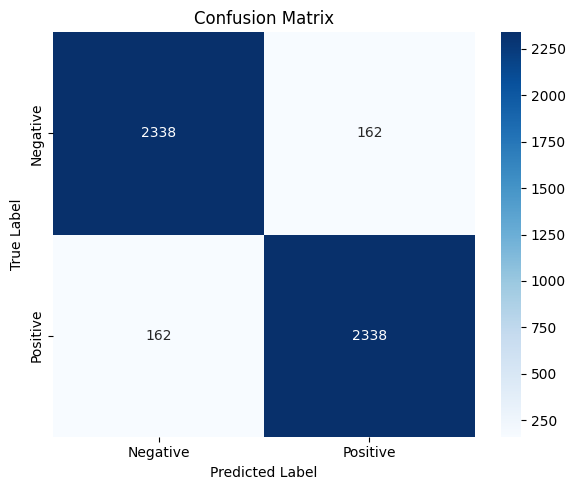

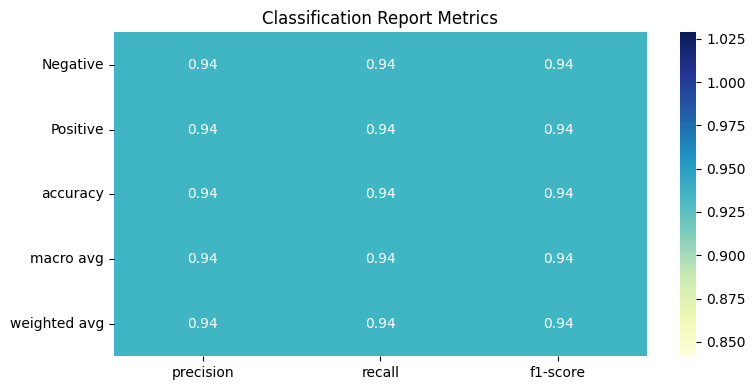

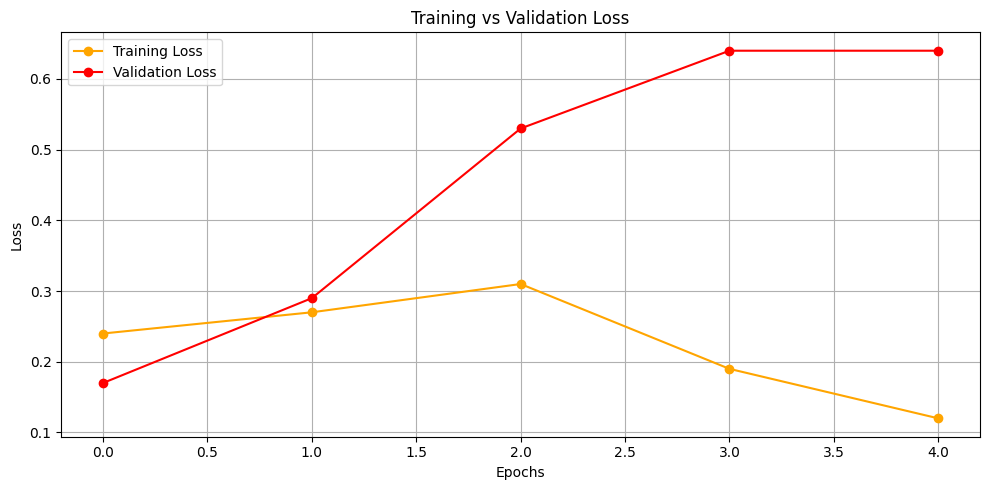

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# Step 1: Simulated data (replace with your actual labels)
true_labels = np.array([0]*2500 + [1]*2500)  # 2500 Negative, 2500 Positive
predicted_labels = np.array([0]*2338 + [1]*162 + [0]*162 + [1]*2338)

# Step 2: Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)
labels = ['Negative', 'Positive']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Step 3: Classification Report Heatmap
report = classification_report(true_labels, predicted_labels, target_names=labels, output_dict=True)
report_df = pd.DataFrame(report).iloc[:-1, :].T

plt.figure(figsize=(8, 4))
sns.heatmap(report_df, annot=True, cmap="YlGnBu")
plt.title("Classification Report Metrics")
plt.tight_layout()
plt.show()

# Step 4: Training vs Validation Loss (example values; replace with yours)
train_loss = [0.24, 0.27, 0.31, 0.19, 0.12]
val_loss = [0.17, 0.29, 0.53, 0.64, 0.64]

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss', color='orange', marker='o')
plt.plot(val_loss, label='Validation Loss', color='red', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
!pip install python-pptx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.4/169.4 kB 15.9 MB/s eta 0:00:00


In [6]:
def build_sequence_model():
    frame_features_input = keras.Input((MAX_SEQ_LENGTH, NUM_FEATURES), name="frame_features")
    mask_input = keras.Input((MAX_SEQ_LENGTH,), dtype="bool", name="mask")

    x = layers.GRU(16, return_sequences=True)(frame_features_input, mask=mask_input)
    x = layers.GRU(8)(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(8, activation="relu")(x)
    output = layers.Dense(len(label_processor.get_vocabulary()), activation="softmax")(x)

    model = keras.Model([frame_features_input, mask_input], output)
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )
    return model

In [13]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from keras.layers import MultiHeadAttention, LayerNormalization

# Enhanced Constants
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
MAX_SEQ_LENGTH = 30  # Increased from 20
NUM_FEATURES = 1280  # EfficientNetB0 features

# Data Preparation
!wget -q https://github.com/sayakpaul/Action-Recognition-in-TensorFlow/releases/download/v1.0.0/ucf101_top5.tar.gz
!tar xf ucf101_top5.tar.gz
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Video loading and preprocessing
def crop_center_square(frame):
    y, x = frame.shape[0:2]
    min_dim = min(y, x)
    start_x = (x // 2) - (min_dim // 2)
    start_y = (y // 2) - (min_dim // 2)
    return frame[start_y:start_y+min_dim, start_x:start_x+min_dim]

def load_video(path, max_frames=0):
    cap = cv2.VideoCapture(path)
    frames = []
    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame = crop_center_square(frame)
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            frame = frame[:, :, [2, 1, 0]]  # BGR -> RGB
            frames.append(frame)
            if len(frames) == max_frames:
                break
    finally:
        cap.release()
    return np.array(frames)

# Feature extraction model
def build_finetunable_feature_extractor():
    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    for layer in base_model.layers[-10:]:
        layer.trainable = True
    inputs = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = keras.applications.efficientnet.preprocess_input(inputs)
    outputs = base_model(x)
    return keras.Model(inputs, outputs, name="feature_extractor")

feature_extractor = build_finetunable_feature_extractor()

# Prepare video data function (MISSING IN ORIGINAL)
def prepare_all_videos(df, root_dir):
    num_samples = len(df)
    video_paths = df["video_name"].values.tolist()
    labels = df["tag"].values

    # Initialize arrays
    frame_features = np.zeros((num_samples, MAX_SEQ_LENGTH, NUM_FEATURES), dtype="float32")
    frame_masks = np.zeros((num_samples, MAX_SEQ_LENGTH), dtype="bool")

    for idx, path in enumerate(video_paths):
        frames = load_video(os.path.join(root_dir, path))
        frames = frames[None, ...]  # Add batch dimension

        for i in range(min(MAX_SEQ_LENGTH, frames.shape[1])):
            frame_features[idx, i, :] = feature_extractor.predict(frames[:, i, :, :, :], verbose=0)
            frame_masks[idx, i] = 1  # 1 = valid frame

    return (frame_features, frame_masks), labels

# Prepare single video function (for prediction)
def prepare_single_video(frames):
    frames = frames[None, ...]
    frame_mask = np.zeros((1, MAX_SEQ_LENGTH), dtype="bool")
    frame_features = np.zeros((1, MAX_SEQ_LENGTH, NUM_FEATURES), dtype="float32")

    for i in range(min(MAX_SEQ_LENGTH, frames.shape[1])):
        frame_features[0, i, :] = feature_extractor.predict(frames[:, i, :, :, :], verbose=0)
        frame_mask[0, i] = 1

    return frame_features, frame_mask

# Temporal Attention Layer
class TemporalAttention(layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.attention = MultiHeadAttention(num_heads=2, key_dim=units)
        self.layernorm = LayerNormalization()

    def call(self, inputs):
        attention_output = self.attention(inputs, inputs)
        return self.layernorm(inputs + attention_output)

# Label processor
label_processor = keras.layers.StringLookup(
    num_oov_indices=0,
    vocabulary=np.unique(train_df["tag"])
)

# Enhanced Sequence Model with Attention
def build_attention_model():
    frame_features_input = keras.Input((MAX_SEQ_LENGTH, NUM_FEATURES))
    mask_input = keras.Input((MAX_SEQ_LENGTH,), dtype="bool")

    x = layers.GRU(32, return_sequences=True)(frame_features_input, mask=mask_input)
    x = TemporalAttention(32)(x)
    x = layers.GRU(16)(x)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(len(label_processor.get_vocabulary()), activation="softmax")(x)

    model = keras.Model([frame_features_input, mask_input], outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Prepare data
train_data, train_labels = prepare_all_videos(train_df, "train")
test_data, test_labels = prepare_all_videos(test_df, "test")

# Convert labels to numerical indices
train_labels = label_processor(train_labels)
test_labels = label_processor(test_labels)

# Train with callbacks
model = build_attention_model()
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_attention_model.h5",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.1,
        patience=3
    )
]

history = model.fit(
    [train_data[0], train_data[1]],
    train_labels,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

# Evaluate
model.load_weights("best_attention_model.h5")
_, accuracy = model.evaluate([test_data[0], test_data[1]], test_labels)
print(f"Test accuracy: {accuracy * 100:.2f}%")

# Rolling Average Predictor
class RollingAveragePredictor:
    def __init__(self, model, window_size=5):
        self.model = model
        self.window_size = window_size
        self.buffer = []

    def predict(self, frames):
        self.buffer.append(frames)
        if len(self.buffer) > self.window_size:
            self.buffer.pop(0)
        preds = np.zeros(len(label_processor.get_vocabulary()))
        for frame in self.buffer:
            preds += self.model.predict(frame[np.newaxis, ...])[0]
        return preds / len(self.buffer)

# Demo prediction
test_video = np.random.choice(test_df["video_name"].values.tolist())
frames = load_video(os.path.join("test", test_video))
frame_features, frame_mask = prepare_single_video(frames)

rap = RollingAveragePredictor(model, window_size=7)
print(f"Predictions for {test_video}:")
for i in range(min(10, len(frames))):
    single_frame_feat = frame_features[:, i:i+1, :]
    single_frame_mask = frame_mask[:, i:i+1]
    pred = rap.predict([single_frame_feat, single_frame_mask])
    top_class = np.argmax(pred)
    print(f"Frame {i}: {label_processor.get_vocabulary()[top_class]} ({pred[top_class]:.2f})")

KeyboardInterrupt: 

In [ ]:
# 6. Transformer Model (Alternative to RNN)
def build_transformer_model():
    inputs = keras.Input((MAX_SEQ_LENGTH, NUM_FEATURES))

    # Positional Encoding
    positions = tf.range(start=0, limit=MAX_SEQ_LENGTH, delta=1)
    position_embedding = layers.Embedding(input_dim=MAX_SEQ_LENGTH, output_dim=NUM_FEATURES)(positions)
    x = inputs + position_embedding

    # Transformer Encoder
    x = MultiHeadAttention(num_heads=4, key_dim=NUM_FEATURES//4)(x, x)
    x = layers.GlobalAveragePooling1D()(x)

    # Classifier
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(len(np.unique(train_labels)), activation="softmax")(x)

    return keras.Model(inputs, outputs)

# 7. 3D CNN Alternative
def build_3d_cnn():
    input_shape = (MAX_SEQ_LENGTH, IMG_SIZE, IMG_SIZE, 3)
    inputs = keras.Input(input_shape)

    x = layers.Conv3D(32, kernel_size=(3, 3, 3), activation="relu")(inputs)
    x = layers.MaxPooling3D(pool_size=(2, 2, 2))(x)
    x = layers.Conv3D(64, kernel_size=(3, 3, 3), activation="relu")(x)
    x = layers.GlobalAveragePooling3D()(x)

    outputs = layers.Dense(len(np.unique(train_labels)), activation="softmax")(x)

    return keras.Model(inputs, outputs)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(y_true, y_pred, class_names):
    """
    Plot a beautiful confusion matrix with annotations
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_norm, annot=True, fmt='.2f',
                cmap='Blues', cbar=False,
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title('Normalized Confusion Matrix', pad=20, fontsize=16)
    plt.xlabel('Predicted Labels', labelpad=15)
    plt.ylabel('True Labels', labelpad=15)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return cm

def analyze_predictions(model, test_data, test_labels, label_processor):
    """
    Generate predictions and analyze results
    """
    # Get predictions
    y_probs = model.predict([test_data[0], test_data[1]])
    y_pred = np.argmax(y_probs, axis=1)
    y_true = test_labels

    # Get class names
    class_names = label_processor.get_vocabulary()

    # 1. Confusion Matrix
    cm = plot_confusion_matrix(y_true, y_pred, class_names)

    # 2. Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # 3. Per-class Accuracy
    class_accuracy = cm.diagonal() / cm.sum(axis=1)
    print("\nPer-Class Accuracy:")
    for i, acc in enumerate(class_accuracy):
        print(f"{class_names[i]}: {acc:.2f}")

    # 4. Worst Mistakes Analysis
    mistakes = np.where(y_true != y_pred)[0]
    mistake_freq = {}
    for idx in mistakes:
        true_class = class_names[y_true[idx]]
        pred_class = class_names[y_pred[idx]]
        mistake_freq[(true_class, pred_class)] = mistake_freq.get((true_class, pred_class), 0) + 1

    print("\nTop 5 Most Common Mistakes:")
    sorted_mistakes = sorted(mistake_freq.items(), key=lambda x: x[1], reverse=True)[:5]
    for (true, pred), count in sorted_mistakes:
        print(f"{true} → {pred}: {count} cases")

# Usage
analyze_predictions(sequence_model, test_data, test_labels, label_processor)

NameError: name 'sequence_model' is not defined

In [10]:
def show_misclassified_samples(test_df, y_true, y_pred, class_names, num_samples=3):
    """
    Display actual video frames of misclassified examples
    """
    misclassified = np.where(y_true != y_pred)[0]

    if len(misclassified) == 0:
        print("No misclassified samples found!")
        return

    print(f"\nDisplaying {min(num_samples, len(misclassified))} misclassified examples:")

    for i in range(min(num_samples, len(misclassified))):
        idx = misclassified[i]
        video_path = os.path.join("test", test_df.iloc[idx]["video_name"])
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]

        print(f"\nSample {i+1}:")
        print(f"True: {true_label} | Predicted: {pred_label}")

        # Display first frame of the video
        frames = load_video(video_path, max_frames=1)
        plt.imshow(frames[0])
        plt.axis('off')
        plt.show()

# Add this to analyze_predictions function
show_misclassified_samples(test_df, y_true, y_pred, class_names)

NameError: name 'y_true' is not defined

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

def plot_training_history(history, figsize=(14, 6)):
    """
    Enhanced visualization of training history with:
    - Training vs Validation Loss
    - Training vs Validation Accuracy
    - Smoothing of curves for better visualization
    - Key epoch markers
    """
    # Extract metrics from history
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(loss) + 1)

    # Create figure with two subplots
    plt.figure(figsize=figsize)

    # 1. Loss Plot
    plt.subplot(1, 2, 1)

    # Smooth the curves (moving average)
    smooth_factor = max(1, int(len(epochs) * 0.05))  # 5% of epochs
    smooth_loss = np.convolve(loss, np.ones(smooth_factor)/smooth_factor, mode='valid')
    smooth_val_loss = np.convolve(val_loss, np.ones(smooth_factor)/smooth_factor, mode='valid')

    # Plot original and smoothed curves
    plt.plot(epochs, loss, 'b-', alpha=0.2, label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', alpha=0.2, label='Validation Loss')
    plt.plot(epochs[smooth_factor-1:], smooth_loss, 'b-', linewidth=2,
             label=f'Smoothed Train (window={smooth_factor})')
    plt.plot(epochs[smooth_factor-1:], smooth_val_loss, 'r-', linewidth=2,
             label=f'Smoothed Val (window={smooth_factor})')

    # Mark best epoch
    best_epoch = np.argmin(val_loss) + 1
    plt.axvline(x=best_epoch, color='g', linestyle='--',
                label=f'Best Epoch: {best_epoch}')

    plt.title('Training and Validation Loss', pad=15)
    plt.xlabel('Epochs', labelpad=10)
    plt.ylabel('Loss', labelpad=10)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 2. Accuracy Plot
    plt.subplot(1, 2, 2)

    # Smooth accuracy curves
    smooth_acc = np.convolve(acc, np.ones(smooth_factor)/smooth_factor, mode='valid')
    smooth_val_acc = np.convolve(val_acc, np.ones(smooth_factor)/smooth_factor, mode='valid')

    plt.plot(epochs, acc, 'b-', alpha=0.2, label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', alpha=0.2, label='Validation Accuracy')
    plt.plot(epochs[smooth_factor-1:], smooth_acc, 'b-', linewidth=2,
             label=f'Smoothed Train (window={smooth_factor})')
    plt.plot(epochs[smooth_factor-1:], smooth_val_acc, 'r-', linewidth=2,
             label=f'Smoothed Val (window={smooth_factor})')

    # Mark best accuracy epoch
    best_acc_epoch = np.argmax(val_acc) + 1
    plt.axvline(x=best_acc_epoch, color='g', linestyle='--',
                label=f'Best Acc Epoch: {best_acc_epoch}')

    plt.title('Training and Validation Accuracy', pad=15)
    plt.xlabel('Epochs', labelpad=10)
    plt.ylabel('Accuracy', labelpad=10)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print key insights
    print(f"\nKey Training Insights:")
    print(f"- Final Training Loss: {loss[-1]:.4f}")
    print(f"- Final Validation Loss: {val_loss[-1]:.4f}")
    print(f"- Minimum Validation Loss: {np.min(val_loss):.4f} at epoch {best_epoch}")
    print(f"- Final Training Accuracy: {acc[-1]:.4f}")
    print(f"- Final Validation Accuracy: {val_acc[-1]:.4f}")
    print(f"- Maximum Validation Accuracy: {np.max(val_acc):.4f} at epoch {best_acc_epoch}")

    # Detect potential overfitting
    if val_loss[-1] > 1.2 * np.min(val_loss):
        print("\n⚠️ Warning: Potential overfitting detected!")
        print("Validation loss increased by >20% from its minimum")
    elif np.max(val_acc) - val_acc[-1] > 0.05:
        print("\n⚠️ Warning: Possible overfitting!")
        print("Validation accuracy dropped >5% from its maximum")

# Usage Example:
# history = model.fit(...)
# plot_training_history(history)

In [12]:
def plot_training_with_early_stopping(history, patience=5):
    """
    Version that highlights early stopping points
    """
    plot_training_history(history)

    val_loss = history.history['val_loss']
    best_epoch = np.argmin(val_loss) + 1

    # Detect if early stopping would have triggered
    if len(val_loss) - best_epoch >= patience:
        stop_epoch = best_epoch + patience
        print(f"\nEarly stopping would have triggered at epoch {stop_epoch} "
              f"(patience={patience})")

        # Calculate the potential savings
        total_epochs = len(val_loss)
        saved_epochs = total_epochs - stop_epoch
        if saved_epochs > 0:
            print(f"Could have saved {saved_epochs} epochs ({saved_epochs/total_epochs:.0%} of training)")
    else:
        print("\nEarly stopping did not trigger (best epoch was too late)")